In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("..\\data\\raw\\cicids2017_100k.csv")

print(df.shape)
df.head()

(100000, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,53,162.0,2.0,2.0,70.0,102.0,35.0,35.0,35.0,0.000000,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,10180,3.0,2.0,0.0,4.0,0.0,2.0,2.0,2.0,0.000000,...,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,53,37703637.0,2.0,2.0,100.0,203.0,54.0,46.0,50.0,5.656854,...,20.0,49953.0,0.0,49953.0,49953.0,37418890.0,0.0,37418890.0,37418890.0,BENIGN
3,53,30530.0,1.0,1.0,44.0,60.0,44.0,44.0,44.0,0.000000,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,5009,44.0,1.0,1.0,0.0,6.0,0.0,0.0,0.0,0.000000,...,40.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PortScan


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 79 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             100000 non-null  int64  
 1   Flow Duration                100000 non-null  float64
 2   Total Fwd Packets            100000 non-null  float64
 3   Total Backward Packets       100000 non-null  float64
 4   Total Length of Fwd Packets  100000 non-null  float64
 5   Total Length of Bwd Packets  100000 non-null  float64
 6   Fwd Packet Length Max        100000 non-null  float64
 7   Fwd Packet Length Min        100000 non-null  float64
 8   Fwd Packet Length Mean       100000 non-null  float64
 9   Fwd Packet Length Std        100000 non-null  float64
 10  Bwd Packet Length Max        100000 non-null  float64
 11  Bwd Packet Length Min        100000 non-null  float64
 12  Bwd Packet Length Mean       100000 non-null  float64
 13  Bwd Packet 

In [4]:
df.describe()

c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,100000.000000,1.000000e+05,100000.000000,100000.000000,1.000000e+05,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.00000,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05
mean,7899.845360,1.575941e+07,11.272330,12.833050,7.074427e+02,2.244649e+04,219.282400,18.021730,61.380651,75.298078,...,8.454310,26.16801,8.546380e+04,3.739433e+04,1.490130e+05,6.421817e+04,9.716148e+06,6.012585e+05,1.017161e+07,9.252161e+06
std,17984.098059,3.443698e+07,1026.082724,1356.948578,4.157637e+04,3.099935e+06,789.435354,64.313922,205.178248,313.881384,...,986.970071,6.63330,7.732503e+05,3.546758e+05,1.045367e+06,7.273457e+05,2.574305e+07,5.067939e+06,2.653613e+07,2.547465e+07
min,0.000000,-1.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,53.000000,1.370000e+02,2.000000,1.000000,6.000000e+00,6.000000e+00,6.000000,0.000000,6.000000,0.000000,...,0.000000,20.00000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.000000,3.128050e+04,2.000000,2.000000,6.000000e+01,1.200000e+02,36.000000,2.000000,33.000000,0.000000,...,1.000000,24.00000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,443.000000,4.348277e+06,5.000000,5.000000,2.800000e+02,6.520000e+02,143.250000,34.000000,50.000000,27.135463,...,2.000000,32.00000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,65510.000000,1.199998e+08,217797.000000,289585.000000,1.290000e+07,6.396506e+08,23360.000000,1983.000000,4141.771429,5796.500690,...,207409.000000,93.00000,1.100000e+08,3.740000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.340000e+07,1.200000e+08,1.200000e+08


Nhận xét: Kết quả thống kê mô tả cho thấy các đặc trưng trong tập dữ liệu có phạm vi giá trị rất khác nhau. Nhiều biến như Flow Duration, Total Fwd Packets và Total Backward Packets có độ lệch chuẩn lớn hơn nhiều so với giá trị trung bình, cho thấy dữ liệu phân tán mạnh và tồn tại các giá trị ngoại lệ. Bên cạnh đó, sự chênh lệch đáng kể giữa giá trị nhỏ nhất và lớn nhất của nhiều đặc trưng phản ánh tính đa dạng của lưu lượng mạng trong tập dữ liệu. Điều này cho thấy cần thực hiện bước chuẩn hóa dữ liệu trước khi huấn luyện mô hình nhằm giảm ảnh hưởng của sự khác biệt về thang đo giữa các đặc trưng.

In [5]:
missing = df.isnull().sum()

missing[missing > 0]

Flow Bytes/s    49
dtype: int64

In [6]:
df = df.dropna()

In [7]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 4313


In [8]:
df.drop_duplicates(inplace=True)

In [9]:
numeric_cols = df.select_dtypes(include=np.number)

np.isinf(numeric_cols).sum()

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
                              ..
Active Min                     0
Idle Mean                      0
Idle Std                       0
Idle Max                       0
Idle Min                       0
Length: 78, dtype: int64

In [10]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

In [11]:
label_counts = df['Label'].value_counts()

print(label_counts)

Label
BENIGN              73679
DoS Hulk             8183
PortScan             6887
DDoS                 5781
DoS GoldenEye         465
DoS slowloris         261
DoS Slowhttptest      241
Bot                    89
Infiltration            2
Name: count, dtype: int64


In [12]:
df['Label'].value_counts(normalize=True)*100

Label
BENIGN              77.079759
DoS Hulk             8.560698
PortScan             7.204879
DDoS                 6.047830
DoS GoldenEye        0.486463
DoS slowloris        0.273047
DoS Slowhttptest     0.252124
Bot                  0.093108
Infiltration         0.002092
Name: proportion, dtype: float64

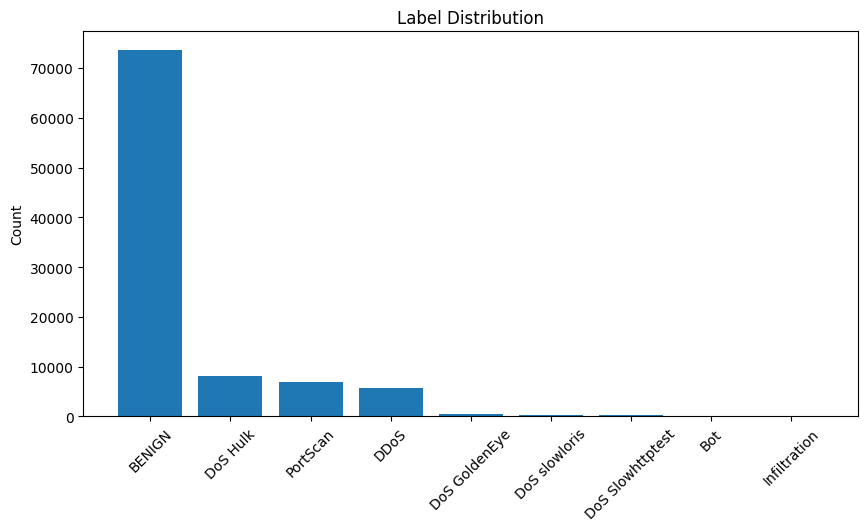

In [13]:
plt.figure(figsize=(10,5))

plt.bar(label_counts.index,
        label_counts.values)

plt.xticks(rotation=45)

plt.title("Label Distribution")

plt.ylabel("Count")

plt.savefig('../outputs/figures/Label_Distribution.png')
plt.show()

Nhận xét: 
1. Lớp BENIGN chiếm ưu thế tuyệt đối
Lớp BENIGN có khoảng 74.000 mẫu, lớn hơn rất nhiều so với tất cả các lớp tấn công.
Đây là lớp đại diện cho lưu lượng mạng bình thường và chiếm phần lớn tập dữ liệu.
2. Các lớp tấn công chính có số lượng thấp hơn nhiều
DoS Hulk khoảng 8.000 mẫu.
PortScan khoảng 7.000 mẫu.
DDoS khoảng 6.000 mẫu.
Mặc dù đây là các lớp tấn công có nhiều dữ liệu nhất, số lượng mẫu vẫn chỉ bằng khoảng 8–11% so với lớp BENIGN.
3. Một số lớp có rất ít mẫu
DoS GoldenEye
DoS slowloris
DoS Slowhttptest
Bot
Infiltration
Các lớp này chỉ có vài trăm hoặc thậm chí vài chục mẫu, thấp hơn rất nhiều so với lớp BENIGN.
4. Mức độ mất cân bằng dữ liệu rất cao
Chênh lệch giữa lớp lớn nhất (BENIGN) và lớp nhỏ nhất (Infiltration) lên tới hàng nghìn lần.
Điều này khiến mô hình Machine Learning có xu hướng học tốt lớp đa số nhưng dự đoán kém các lớp thiểu số.
5. Tác động đến quá trình xây dựng mô hình
Accuracy có thể đạt giá trị cao nhưng không phản ánh đúng chất lượng mô hình.
Các lớp tấn công hiếm có nguy cơ bị bỏ sót khi dự đoán.
Cần sử dụng các chỉ số đánh giá như:
Precision
Recall
F1-score
Macro F1
Có thể cân nhắc các kỹ thuật xử lý mất cân bằng như:
Class Weight
Oversampling (SMOTE)
Undersampling

Biểu đồ phân phối nhãn cho thấy tập dữ liệu CICIDS2017 có sự mất cân bằng rất lớn giữa lưu lượng bình thường và các loại tấn công. Lớp BENIGN chiếm đa số trong khi nhiều lớp tấn công chỉ xuất hiện với số lượng rất nhỏ. Đây là một thách thức quan trọng đối với bài toán phát hiện xâm nhập mạng và cần được xem xét trong quá trình huấn luyện và đánh giá mô hình.

In [14]:
for col in df.columns:
    if df[col].nunique() == 1:
        print(col)

Bwd PSH Flags
Bwd URG Flags
Fwd Avg Bytes/Bulk
Fwd Avg Packets/Bulk
Fwd Avg Bulk Rate
Bwd Avg Bytes/Bulk
Bwd Avg Packets/Bulk
Bwd Avg Bulk Rate


In [15]:
constant_cols = [
    col for col in df.columns
    if df[col].nunique() == 1
]

df = df.drop(columns=constant_cols)

Nhận xét: Các cột Bwd PSH Flags, Bwd URG Flags, Fwd Avg Bytes/Bulk, Fwd Avg Packets/Bulk, Fwd Avg Bulk Rate, Bwd Avg Bytes/Bulk, Bwd Avg Packets/Bulk và Bwd Avg Bulk Rate đều chỉ chứa một giá trị duy nhất trong toàn bộ tập dữ liệu. Do không có khả năng phân biệt giữa các lớp và không đóng góp thông tin cho mô hình, các cột này được loại bỏ khỏi tập dữ liệu.

In [16]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# Tạo biến mới để tránh ảnh hưởng tới df gốc
X_mi = df.drop(columns=['Label'])
y_mi = df['Label']

# Chỉ lấy các cột số
X_mi = X_mi.select_dtypes(include=np.number)

# Mã hóa nhãn
le = LabelEncoder()
y_mi_encoded = le.fit_transform(y_mi)

# Tính Mutual Information
mi_scores = mutual_info_classif(
    X_mi,
    y_mi_encoded,
    random_state=42
)

mi_df = pd.DataFrame({
    'Feature': X_mi.columns,
    'MI_Score': mi_scores
})

# Sắp xếp giảm dần
mi_df = mi_df.sort_values(
    by='MI_Score',
    ascending=False
)

# Hiển thị 40 đặc trưng quan trọng nhất
print(mi_df.head(40))

                        Feature  MI_Score
50          Average Packet Size  0.662515
39            Packet Length Std  0.642420
40       Packet Length Variance  0.639640
38           Packet Length Mean  0.627874
57            Subflow Bwd Bytes  0.590306
5   Total Length of Bwd Packets  0.590051
4   Total Length of Fwd Packets  0.575489
55            Subflow Fwd Bytes  0.575084
12       Bwd Packet Length Mean  0.572058
52         Avg Bwd Segment Size  0.569977
59      Init_Win_bytes_backward  0.538557
10        Bwd Packet Length Max  0.536291
58       Init_Win_bytes_forward  0.533253
6         Fwd Packet Length Max  0.515460
37            Max Packet Length  0.507505
18                 Flow IAT Max  0.498413
23                  Fwd IAT Max  0.495721
53          Fwd Header Length.1  0.494647
32            Fwd Header Length  0.492075
20                Fwd IAT Total  0.481070
1                 Flow Duration  0.479850
14                 Flow Bytes/s  0.469438
0              Destination Port  0


Sau khi hoàn thành bước tiền xử lý dữ liệu, nhóm sử dụng phương pháp Mutual Information để đánh giá mức độ ảnh hưởng của từng đặc trưng đối với nhãn phân loại Label. Phương pháp này đo lường lượng thông tin mà một đặc trưng cung cấp về biến mục tiêu Label. Giá trị MI càng lớn chứng tỏ đặc trưng càng có khả năng phân biệt các loại lưu lượng mạng khác nhau. Kết quả cho thấy nhiều đặc trưng có giá trị Mutual Information cao, chứng tỏ chúng chứa nhiều thông tin hữu ích cho việc phân biệt giữa lưu lượng mạng bình thường và các loại tấn công.


In [17]:
selected_features = [
    'Flow Duration',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Packet Length Mean',
    'Packet Length Std',
    'Average Packet Size',
    'Flow IAT Mean',
    'Flow IAT Std',
    'SYN Flag Count',
    'ACK Flag Count',
    'Label'
]

df_eda = df[selected_features]

Tuy nhiên, quá trình khảo sát Top 40 đặc trưng quan trọng nhất cũng cho thấy nhiều đặc trưng đang mô tả cùng một loại thông tin. Chẳng hạn, các đặc trưng Average Packet Size, Packet Length Mean, Packet Length Std và Packet Length Variance đều phản ánh đặc điểm kích thước gói tin. Tương tự, nhiều đặc trưng khác cùng mô tả lưu lượng dữ liệu, số lượng gói tin hoặc đặc điểm thời gian của luồng mạng. Nếu giữ lại toàn bộ các đặc trưng này sẽ làm tăng số chiều dữ liệu, gây dư thừa thông tin và làm cho quá trình trực quan hóa cũng như huấn luyện mô hình trở nên phức tạp hơn.

Vì vậy, nhóm không lựa chọn đơn thuần các đặc trưng có điểm Mutual Information cao nhất mà tiến hành chọn lọc các đặc trưng tiêu biểu đại diện cho từng nhóm thông tin quan trọng của lưu lượng mạng. Cụ thể, nhóm **thời gian** gồm **Flow Duration, Flow IAT Mean, Flow IAT Std**, nhóm **lưu lượng** gồm **Flow Bytes/s, Flow Packets/s, Total Fwd Packets, Total Backward Packets**, nhóm **kích thước gói tin** gồm **Packet Length Mean, Packet Length Std, Average Packet Size**, nhóm **TCP Flags** gồm **SYN Flag Count, ACK Flag Count**.

Bộ đặc trưng này đảm bảo vừa giữ lại các thông tin có khả năng phân biệt cao đối với nhãn phân loại, vừa đại diện cho nhiều khía cạnh khác nhau của lưu lượng mạng như thời gian luồng, tốc độ truyền dữ liệu, số lượng gói tin, kích thước gói tin và hành vi thiết lập kết nối TCP. Nhờ đó, dữ liệu được giảm từ 78 đặc trưng ban đầu xuống còn 12 đặc trưng tiêu biểu, tạo điều kiện thuận lợi cho quá trình trực quan hóa dữ liệu và xây dựng mô hình phát hiện xâm nhập ở các bước tiếp theo.

**Tại sao không lấy luôn Top 12 Mutual Information?**

Vì nhiều đặc trưng trong Top 12 đang mô tả cùng một loại thông tin. Ví dụ Average Packet Size, Packet Length Mean, Packet Length Std và Packet Length Variance đều liên quan đến kích thước gói tin. Nếu lấy toàn bộ sẽ gây dư thừa thông tin. Nhóm ưu tiên chọn các đặc trưng vừa có mức ảnh hưởng cao vừa đại diện cho nhiều khía cạnh khác nhau của lưu lượng mạng để bộ dữ liệu gọn hơn nhưng vẫn giữ được khả năng phân biệt.

In [18]:
df_eda.head()

,Flow Duration,Flow Bytes/s,Flow Packets/s,Total Fwd Packets,Total Backward Packets,Packet Length Mean,Packet Length Std,Average Packet Size,Flow IAT Mean,Flow IAT Std,SYN Flag Count,ACK Flag Count,Label
0,162.0,1.061728e+06,24691.358020,2.0,2.0,41.400000,8.763561,51.75,54.0,8.833459e+01,0.0,0.0,BENIGN
1,3.0,1.333333e+06,666666.666700,2.0,0.0,2.000000,0.000000,3.00,3.0,0.000000e+00,0.0,0.0,BENIGN
2,37703637.0,8.036360e+00,0.106091,2.0,2.0,71.400000,28.049955,89.25,12567879.0,2.152181e+07,0.0,0.0,BENIGN
3,30530.0,3.406485e+03,65.509335,1.0,1.0,49.333333,9.237604,74.00,30530.0,0.000000e+00,0.0,0.0,BENIGN
4,44.0,1.363636e+05,45454.545450,1.0,1.0,2.000000,3.464102,3.00,44.0,0.000000e+00,0.0,0.0,PortScan


In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])
df['Label'].head()
print(le.classes_)

['BENIGN' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'Infiltration' 'PortScan']


In [20]:
X = df_eda.drop('Label', axis=1)
y = df_eda['Label']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
import joblib
joblib.dump(scaler, '../outputs/models/scaler.pkl')


['../outputs/models/scaler.pkl']

In [23]:
feature_names = X.columns

pd.DataFrame(
    X_train,
    columns=feature_names
).to_csv(
    "../data/processed/X_train.csv",
    index=False
)

pd.DataFrame(
    X_test,
    columns=feature_names
).to_csv(
    "../data/processed/X_test.csv",
    index=False
)

pd.DataFrame(y_train).to_csv(
    "../data/processed/y_train.csv",
    index=False
)

pd.DataFrame(y_test).to_csv(
    "../data/processed/y_test.csv",
    index=False
)